In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("SEMUA LIBRARY OK")

SEMUA LIBRARY OK


In [2]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


# Bike Rental Clustering Analysis

Tujuan analisis ini adalah untuk mengelompokkan pola peminjaman sepeda berdasarkan waktu dan kondisi lingkungan menggunakan metode K-Means Clustering.


In [23]:
import pandas as pd

df = pd.read_csv("../data/hour.csv")
df.head()


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [24]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [25]:
features = [
    "hr",
    "weekday",
    "workingday",
    "temp",
    "hum",
    "windspeed",
    "cnt"
]

X = df[features]
X.head()

,hr,weekday,workingday,temp,hum,windspeed,cnt
0,0,6,0,0.24,0.81,0.0,16
1,1,6,0,0.22,0.80,0.0,40
2,2,6,0,0.22,0.80,0.0,32
3,3,6,0,0.24,0.75,0.0,13
4,4,6,0,0.24,0.75,0.0,1


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [27]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

/Users/beruanggoku/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/beruanggoku/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/beruanggoku/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/beruanggoku/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/beruanggoku/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/beruanggoku/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in m

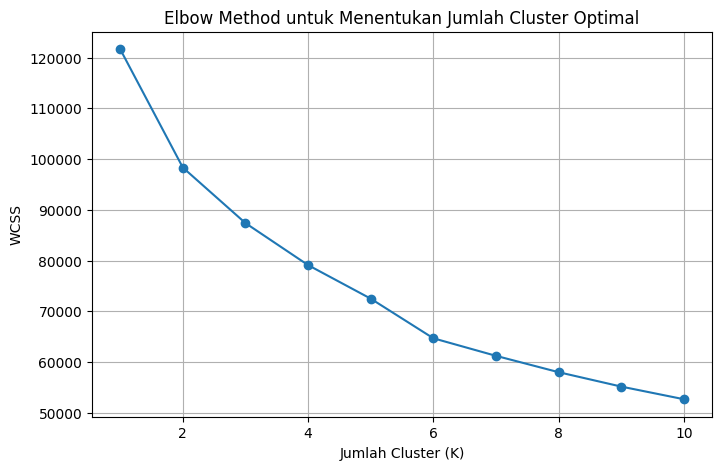

In [28]:
plt.figure(figsize=(8,5))
plt.plot(K_range, wcss, marker='o')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method untuk Menentukan Jumlah Cluster Optimal')
plt.grid(True)
plt.show()

Berdasarkan hasil visualisasi nilai WCSS, maka saya simpulkan bahwa rentang 0 - 2 memiliki penurunan yang cukup drastis. Sehingga, saya mengambil 3 cluster saja sebagai klasifikasi di metode Kmeans

In [36]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

/Users/beruanggoku/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/beruanggoku/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/beruanggoku/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/beruanggoku/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/beruanggoku/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/beruanggoku/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in m

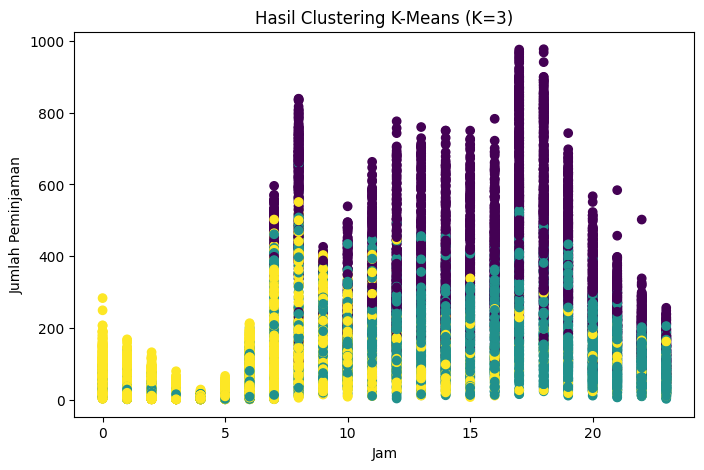

In [37]:
plt.figure(figsize=(8,5))
plt.scatter(df['hr'], df['cnt'], c=df['cluster'], cmap='viridis')
plt.xlabel('Jam')
plt.ylabel('Jumlah Peminjaman')
plt.title('Hasil Clustering K-Means (K=3)')
plt.show()


Visualisasi data untuk gambar diatas dan dibawah sama. Diatas adalah hasil mencoba revisi.

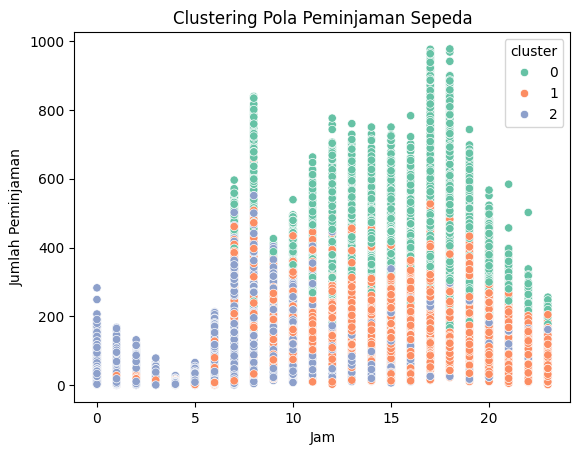

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x="hr",
    y="cnt",
    hue="cluster",
    palette="Set2"
)
plt.title("Clustering Pola Peminjaman Sepeda")
plt.xlabel("Jam")
plt.ylabel("Jumlah Peminjaman")
plt.show()


## Kesimpulan

Berdasarkan hasil clustering, ditemukan beberapa segmen pola peminjaman sepeda yang berbeda. 
Perbedaan ini terutama dipengaruhi oleh jam, hari kerja, dan kondisi lingkungan.
Hasil ini dapat dimanfaatkan untuk perencanaan operasional dan strategi pemasaran.


Dibawah ini merupakan clustering menggunakan metode DBSCAN. Bedanya dengan Kmeans adalah DBSCAN dapat memvisualisasikan data-data yang dianggap sebagai outlier. Data-data tersebut ditandai dengan warna yang berangka -1.

In [32]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=20)
df["cluster_dbscan"] = dbscan.fit_predict(X_scaled)

df["cluster_dbscan"].value_counts()

cluster_dbscan
 2    9891
-1    3101
 1    2344
 0    1962
 3      81
Name: count, dtype: int64

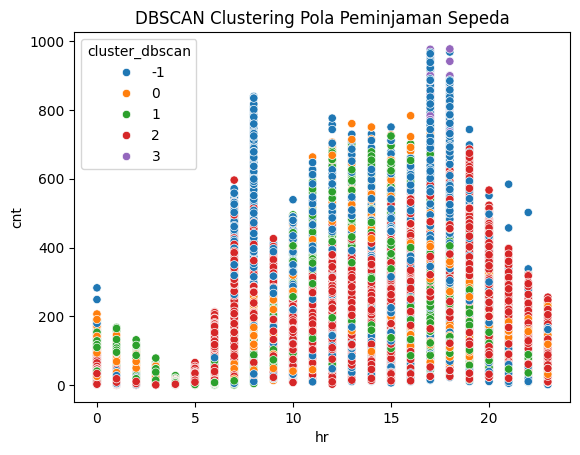

In [33]:
sns.scatterplot(
    data=df,
    x="hr",
    y="cnt",
    hue="cluster_dbscan",
    palette="tab10"
)
plt.title("DBSCAN Clustering Pola Peminjaman Sepeda")
plt.show()


Berdasarkan visualisasi data diatas, maka dapat dilihat bahwa titik-titik berwarna biru merupakan data outlier.

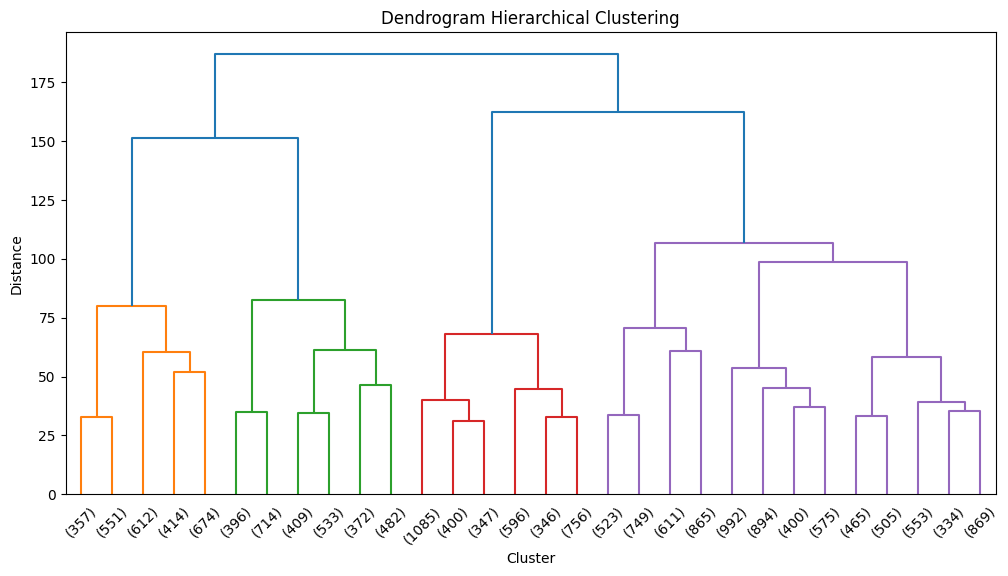

In [34]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode="lastp", p=30)
plt.title("Dendrogram Hierarchical Clustering")
plt.xlabel("Cluster")
plt.ylabel("Distance")
plt.show()

## Perbandingan Metode Clustering

- K-Means efektif dalam membagi data ke dalam cluster berdasarkan rata-rata karakteristik.
- DBSCAN mampu mendeteksi pola kepadatan serta mengidentifikasi data noise.
- Hierarchical clustering memberikan visualisasi struktur data yang membantu dalam pemilihan jumlah cluster.